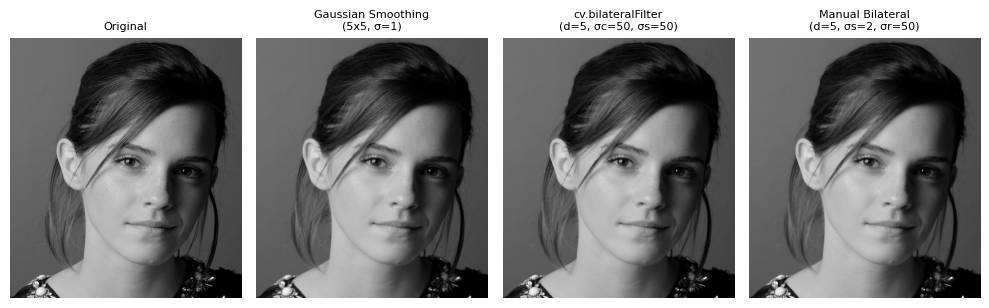

True

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

#Manual Bilateral Filter
def bilateral_manual(img, d, sigma_s, sigma_r):
    img = img.astype(np.float32)
    h, w = img.shape
    half = d // 2
    output = np.zeros_like(img)

    for i in range(h):
        for j in range(w):
            wp_total = 0
            filtered = 0

            for x in range(-half, half + 1):
                for y in range(-half, half + 1):
                    ni = min(max(i + x, 0), h - 1)
                    nj = min(max(j + y, 0), w - 1)

                    # spatial Gaussian
                    gs = np.exp(-(x**2 + y**2) / (2 * sigma_s**2))

                    # range Gaussian
                    gr = np.exp(-((img[i, j] - img[ni, nj])**2) / (2 * sigma_r**2))

                    w_p = gs * gr

                    filtered += img[ni, nj] * w_p
                    wp_total += w_p

            output[i, j] = filtered / wp_total

    return output.astype(np.uint8)

#Load grayscale image
img = cv.imread("/content/input_emma_normal.jpg", cv.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError("Check image path")

#Gaussian Filter
gaussian = cv.GaussianBlur(img, (5, 5), 1)

#OpenCV Bilateral Filter
bilateral_cv = cv.bilateralFilter(img, d=5, sigmaColor=50, sigmaSpace=50)

#Manual Bilateral Filter
bilateral_manual_img = bilateral_manual(img, d=5, sigma_s=2, sigma_r=50)

# -----------------------------------
# Display (compact)
# -----------------------------------
plt.figure(figsize=(10, 3))

plt.subplot(1, 4, 1)
plt.imshow(img, cmap='gray')
plt.title("Original", fontsize=8)
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(gaussian, cmap='gray')
plt.title("Gaussian Smoothing\n(5x5, σ=1)", fontsize=8)
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(bilateral_cv, cmap='gray')
plt.title("cv.bilateralFilter\n(d=5, σc=50, σs=50)", fontsize=8)
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(bilateral_manual_img, cmap='gray')
plt.title("Manual Bilateral\n(d=5, σs=2, σr=50)", fontsize=8)
plt.axis("off")

plt.tight_layout()
plt.savefig("q10_results.png", dpi=300, bbox_inches="tight")
plt.show()

# Save outputs
cv.imwrite("q10_gaussian.png", gaussian)
cv.imwrite("q10_bilateral_cv.png", bilateral_cv)
cv.imwrite("q10_bilateral_manual.png", bilateral_manual_img)